In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r'C:\Users\KIIT0001\Downloads\Expanding_Tata_Steel_product_recommendation_datase-Genspark_AI_Sheets-20260528_1951.xlsx')

In [3]:
df_original = df.copy()

In [4]:
df.head()

,Product_ID,Category,Sub_Category,Product_Variant,Grade,Brand,Thickness_mm,Width_mm,Length_m,Weight_per_Unit_kg,...,Customer_Segment,Region,Manufacturing_Plant,Cost_per_Tonne_INR,Selling_Price_per_Tonne_INR,Sales_Volume_Tonnes,Revenue_INR,Profit_Margin_Pct,Inventory_Tonnes,Customer_Rating
0,TS-L-TMT-001,Long,TMT Bars,Tiscon SuperLinks 550D,Fe-550D,Tiscon,8.0,NaN,12.0,4.74,...,Retail,North,Jamshedpur,52000.0,62500.0,1850.0,115625000.0,0.168000,320.0,4.6
1,TS-L-TMT-002,Long,TMT Bars,Tiscon SuperLinks 550D,Fe-550D,Tiscon,10.0,NaN,12.0,7.40,...,Retail,North,Jamshedpur,51500.0,61800.0,2200.0,135960000.0,0.166667,410.0,4.7
2,TS-L-TMT-003,Long,TMT Bars,Tiscon 500D,Fe-500D,Tiscon,12.0,NaN,12.0,10.66,...,B2B,West,Kalinganagar,50800.0,60500.0,3100.0,187550000.0,0.160331,580.0,4.5
3,TS-L-TMT-004,Long,TMT Bars,Tiscon 500D,Fe-500D,Tiscon,16.0,NaN,12.0,18.96,...,B2B,West,Kalinganagar,50500.0,60000.0,2950.0,177000000.0,0.158333,510.0,4.5
4,TS-L-TMT-005,Long,TMT Bars,Tiscon Premium,Fe-600,Tiscon,20.0,NaN,12.0,29.62,...,Government,South,Jamshedpur,53000.0,64500.0,1620.0,104490000.0,0.178295,290.0,4.8


In [5]:
df.columns

Index(['Product_ID', 'Category', 'Sub_Category', 'Product_Variant', 'Grade',
       'Brand', 'Thickness_mm', 'Width_mm', 'Length_m', 'Weight_per_Unit_kg',
       'Unit_of_Sale', 'Application_Sector', 'Customer_Segment', 'Region',
       'Manufacturing_Plant', 'Cost_per_Tonne_INR',
       'Selling_Price_per_Tonne_INR', 'Sales_Volume_Tonnes', 'Revenue_INR',
       'Profit_Margin_Pct', 'Inventory_Tonnes', 'Customer_Rating'],
      dtype='object')

In [6]:
df['Category'].unique()

array(['Long', 'Flat', nan], dtype=object)

In [7]:
for category in df['Category'].unique():
    print(f"\n{category}:")
    print(df[df['Category'] == category]['Sub_Category'].unique())


Long:
['TMT Bars' 'Wire Rods' 'Structurals' 'Rounds' 'Rails']

Flat:
['Hot Rolled' 'Cold Rolled' 'Galvanized' 'Color Coated' 'Tinplate'
 'Electrical Steel' 'Pipes & Tubes' 'Cold Rolled Coils' 'Hot Rolled Coils']

nan:
[]


In [8]:
df.isnull().sum()

Product_ID                        1
Category                          1
Sub_Category                      1
Product_Variant                   1
Grade                             1
Brand                             1
Thickness_mm                    358
Width_mm                        871
Length_m                        994
Weight_per_Unit_kg             1201
Unit_of_Sale                      1
Application_Sector                1
Customer_Segment                  1
Region                            1
Manufacturing_Plant               1
Cost_per_Tonne_INR                1
Selling_Price_per_Tonne_INR       1
Sales_Volume_Tonnes               1
Revenue_INR                       1
Profit_Margin_Pct                 1
Inventory_Tonnes                  1
Customer_Rating                   1
dtype: int64

In [9]:
df[df["Product_ID"].isnull()]

,Product_ID,Category,Sub_Category,Product_Variant,Grade,Brand,Thickness_mm,Width_mm,Length_m,Weight_per_Unit_kg,...,Customer_Segment,Region,Manufacturing_Plant,Cost_per_Tonne_INR,Selling_Price_per_Tonne_INR,Sales_Volume_Tonnes,Revenue_INR,Profit_Margin_Pct,Inventory_Tonnes,Customer_Rating
1070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.dropna(subset=['Product_ID'], inplace=True)

In [11]:
df.isnull().sum()

Product_ID                        0
Category                          0
Sub_Category                      0
Product_Variant                   0
Grade                             0
Brand                             0
Thickness_mm                    357
Width_mm                        870
Length_m                        993
Weight_per_Unit_kg             1200
Unit_of_Sale                      0
Application_Sector                0
Customer_Segment                  0
Region                            0
Manufacturing_Plant               0
Cost_per_Tonne_INR                0
Selling_Price_per_Tonne_INR       0
Sales_Volume_Tonnes               0
Revenue_INR                       0
Profit_Margin_Pct                 0
Inventory_Tonnes                  0
Customer_Rating                   0
dtype: int64

In [12]:
print("Missing Thickness Values are in the following Subcategories:")
df[df['Thickness_mm'].isnull()]['Sub_Category'].value_counts()

Missing Thickness Values are in the following Subcategories:


Sub_Category
Structurals    317
Rails           40
Name: count, dtype: int64

In [13]:
print("\nMissing Width Values are in the following Subcategories:")
print(df[df['Width_mm'].isnull()]['Sub_Category'].value_counts())


Missing Width Values are in the following Subcategories:
Sub_Category
TMT Bars         394
Wire Rods        277
Rounds           119
Pipes & Tubes     79
Galvanized         1
Name: count, dtype: int64


In [14]:
print("\nMissing Length Values are in the following Subcategories:")
print(df[df['Length_m'].isnull()]['Sub_Category'].value_counts())


Missing Length Values are in the following Subcategories:
Sub_Category
Wire Rods            277
Hot Rolled Coils     192
Cold Rolled Coils    154
Galvanized           119
Tinplate             118
Electrical Steel      78
Color Coated          44
Cold Rolled            6
Hot Rolled             5
Name: count, dtype: int64


In [15]:
df[(df['Sub_Category'] == 'Pipes & Tubes') & (df['Width_mm'].notnull())]

,Product_ID,Category,Sub_Category,Product_Variant,Grade,Brand,Thickness_mm,Width_mm,Length_m,Weight_per_Unit_kg,...,Customer_Segment,Region,Manufacturing_Plant,Cost_per_Tonne_INR,Selling_Price_per_Tonne_INR,Sales_Volume_Tonnes,Revenue_INR,Profit_Margin_Pct,Inventory_Tonnes,Customer_Rating
67,TS-F-PT-002,Flat,Pipes & Tubes,Structural Hollow Sections,YST-310,Tata Structura,4.0,150.0,6.0,NaN,...,B2B,West,Khopoli,60500.0,73000.0,4250.0,310250000.0,0.171233,720.0,4.7
68,TS-F-PT-003,Flat,Pipes & Tubes,Precision Tubes,EN-10305,Tata Precision Tubes,2.0,50.0,6.0,NaN,...,B2B,West,Khopoli,68500.0,83500.0,2180.0,182030000.0,0.179641,370.0,4.8
90,TS-F-PT-1021,Flat,Pipes & Tubes,Structural Hollow Sections,YST-310,Tata Structura,4.0,150.0,6.0,NaN,...,B2B,West,Khopoli,60700.0,73300.0,4371.0,320394300.0,0.171896,743.0,4.7
105,TS-F-PT-1036,Flat,Pipes & Tubes,Precision Tubes,EN-10305,Tata Precision Tubes,2.0,50.0,6.0,NaN,...,B2B,Pan-India,Khopoli,69300.0,84400.0,2014.0,169981600.0,0.178910,372.0,4.8
142,TS-F-PT-1073,Flat,Pipes & Tubes,Structural Hollow Sections,YST-310,Tata Structura,4.0,150.0,6.0,NaN,...,B2B,West,Khopoli,61200.0,74000.0,3965.0,293410000.0,0.172973,781.0,4.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1954,TS-F-PT-2884,Flat,Pipes & Tubes,Precision Tubes,EN-10305,Tata Precision Tubes,2.0,50.0,6.0,NaN,...,B2B,Pan-India,Khopoli,68700.0,83200.0,2342.0,194854400.0,0.174279,390.0,4.7
1987,TS-F-PT-2917,Flat,Pipes & Tubes,Structural Hollow Sections,YST-310,Tata Structura,4.0,150.0,6.0,NaN,...,B2B,West,Khopoli,60200.0,72600.0,4114.0,298676400.0,0.170799,819.0,4.7
2006,TS-F-PT-2936,Flat,Pipes & Tubes,Precision Tubes,EN-10305,Tata Precision Tubes,2.0,50.0,6.0,NaN,...,B2B,South,Khopoli,68800.0,83900.0,2127.0,178455300.0,0.179976,379.0,4.9
2039,TS-F-PT-2969,Flat,Pipes & Tubes,Structural Hollow Sections,YST-310,Tata Structura,4.0,150.0,6.0,NaN,...,B2B,South,Khopoli,60300.0,73400.0,4301.0,315693400.0,0.178474,746.0,4.7


In [16]:
df[df['Sub_Category'] == 'Pipes & Tubes']['Product_Variant'].value_counts()

Product_Variant
ERW Pipes                     40
Structural Hollow Sections    39
Precision Tubes               39
API Line Pipes                39
Name: count, dtype: int64

In [17]:
df[(df['Sub_Category'] == 'Pipes & Tubes') & (df['Width_mm'].isnull())]['Product_Variant'].value_counts()

Product_Variant
ERW Pipes         40
API Line Pipes    39
Name: count, dtype: int64

# **UNIVARIATE ANALYSIS**

## Categorical

#### How many Flat vs Long products are in the dataset? Are they balanced?

Category
Long    1147
Flat     923
Name: count, dtype: int64


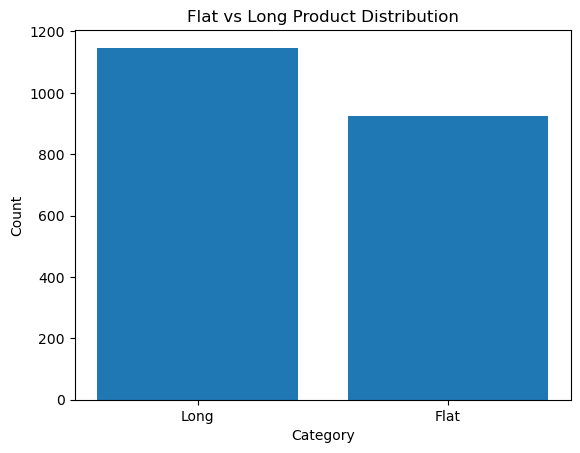

In [20]:
lvf= df['Category'].value_counts()
print(lvf)
plt.bar(lvf.index,lvf)
plt.title('Flat vs Long Product Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

Long products (1147) slightly outnumber Flat products (923).
The dataset is fairly balanced between the two categories.
This means our model has enough data to learn patterns for both.

#### Which sub-category has the most entries?

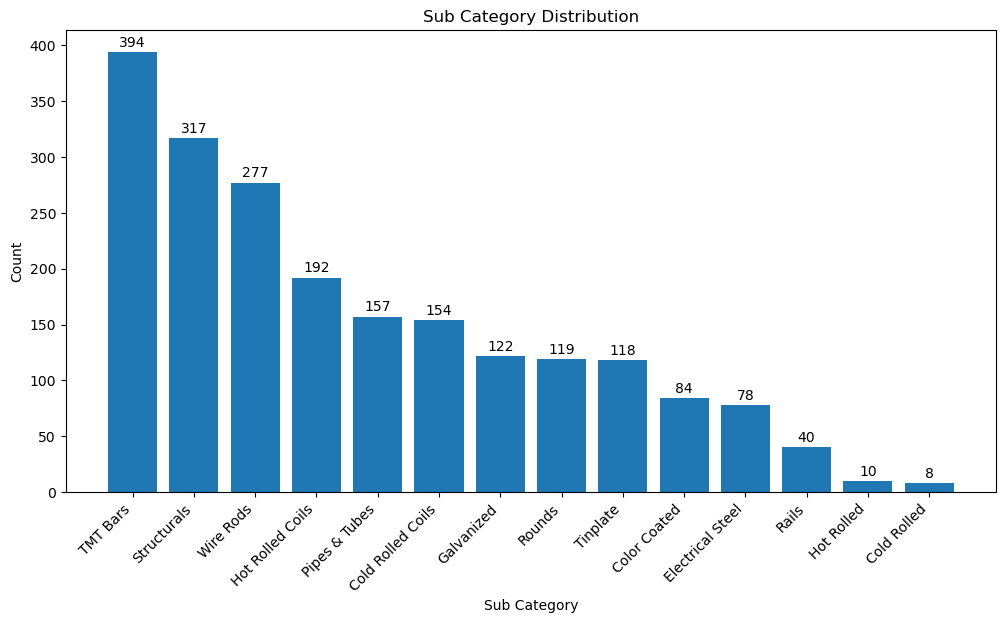

In [23]:
sc = df['Sub_Category'].value_counts()
plt.figure(figsize=(12,6))
plt.bar(sc.index, sc)
plt.title('Sub Category Distribution')
plt.xlabel('Sub Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(sc):
    plt.text(i, v+5 , str(v), ha='center')
plt.show()

TMT Bars (394) has the most entries followed by 
Structurals (317) and Wire Rods (277). All are Long products.
Cold Rolled (8) and Hot Rolled (10) are least represented.
Long products dominate the top entries.

In [25]:
df['Application_Sector'].value_counts() 

Application_Sector
Construction                196
Bridges                     119
Infrastructure              118
Auto Components             117
Residential                  79
Springs                      79
Oil & Gas                    77
Roofing                      43
White Goods                  43
Heavy Construction           41
Industrial Sheds             41
Boilers                      41
Tyre Manufacturing           40
Industrial Roofing           40
Welding                      40
Heavy Forging                40
General Engineering          40
Aerosol Cans                 40
Wire Drawing                 40
Water Supply                 40
Transmission Towers          39
Fasteners                    39
Food Cans                    39
Industrial Buildings         39
Beverage Cans                39
Automotive                   39
Power Transformers           39
Coastal Construction         39
Motors                       39
Seismic Zones                39
Residential Doors    

 Too many unique sectors. For ease we categorize less frequent ones as 'Others'

In [27]:
sector_counts = df['Application_Sector'].value_counts()
top_sectors = sector_counts[sector_counts > 10].index
df['Application_Sector'] = df['Application_Sector'].apply(
    lambda x: x if x in top_sectors else 'Others'
)

#### How many orders per sector?

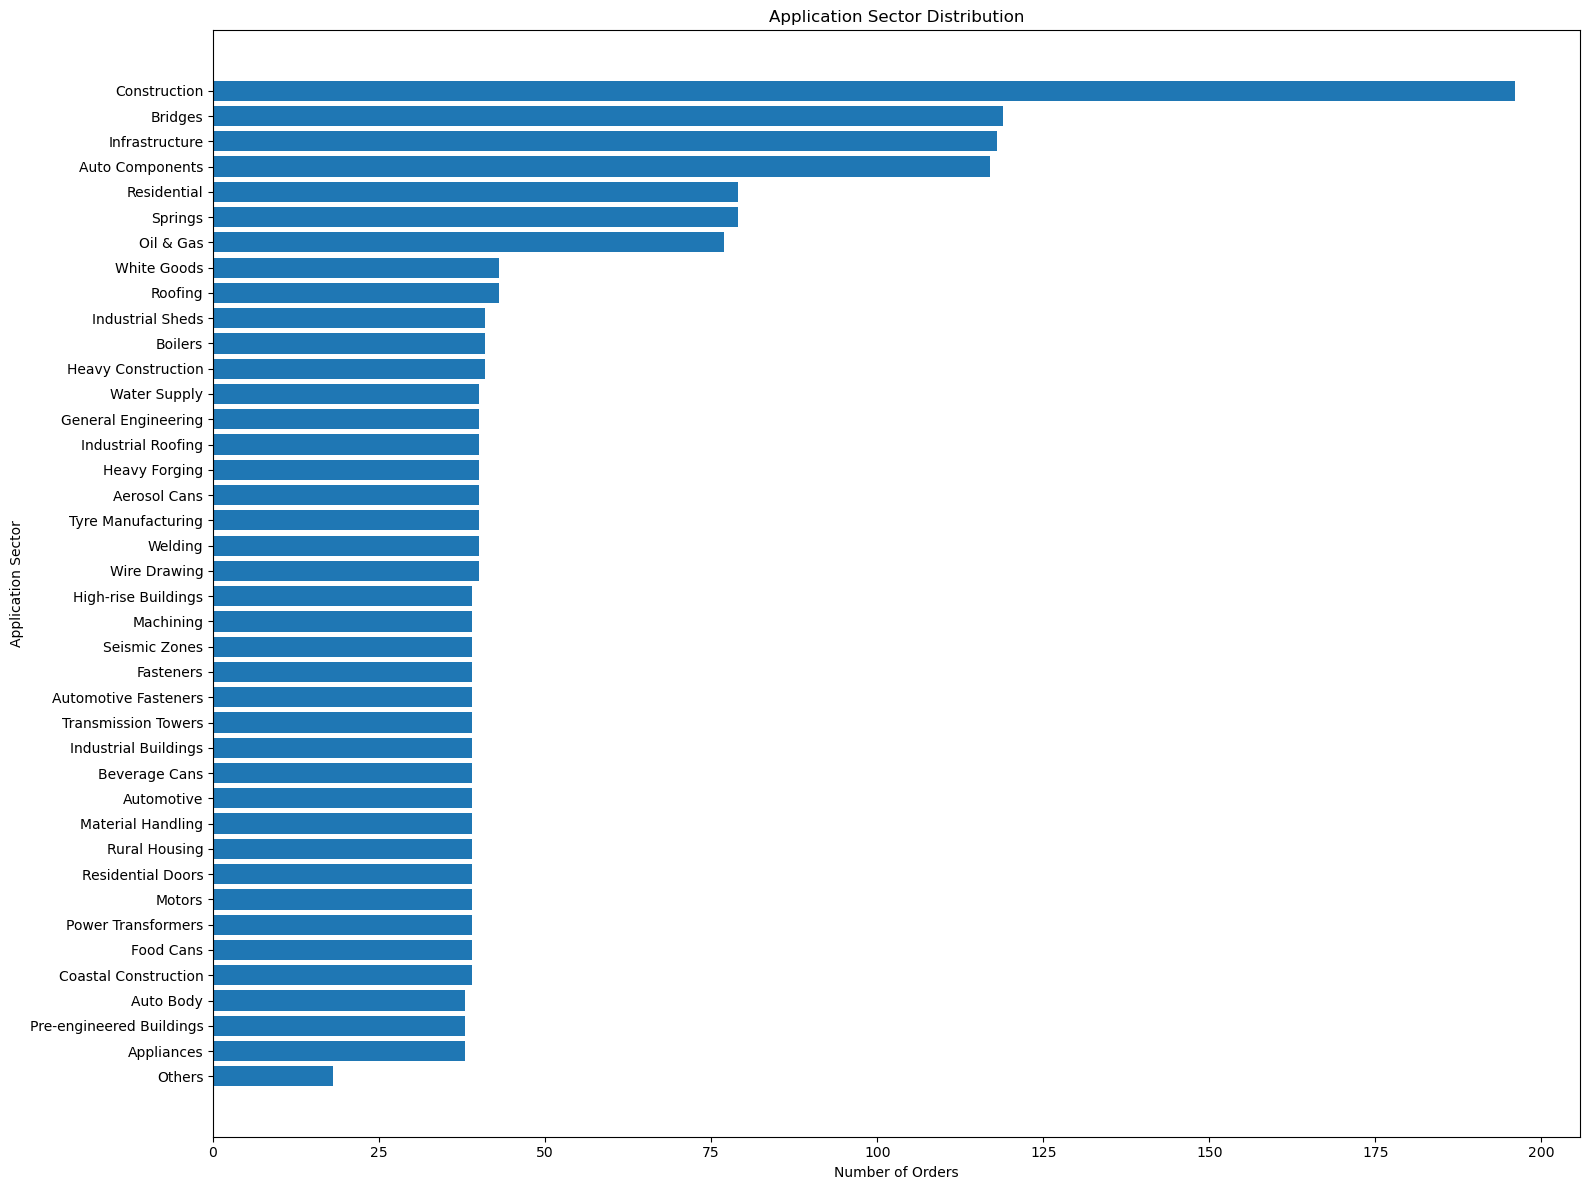

In [29]:
app = df['Application_Sector'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(16,12))
plt.barh(app.index, app)
plt.title('Application Sector Distribution')
plt.ylabel('Application Sector')
plt.xlabel('Number of Orders')
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Construction, Bridges and Infrastructure are all civil/structural sectors, they'll predominantly buy Long products like TMT Bars, Structurals, Rebars. Auto Components will buy Flat products like CRC, Galvanized sheets.

#### Customer Segment Insight

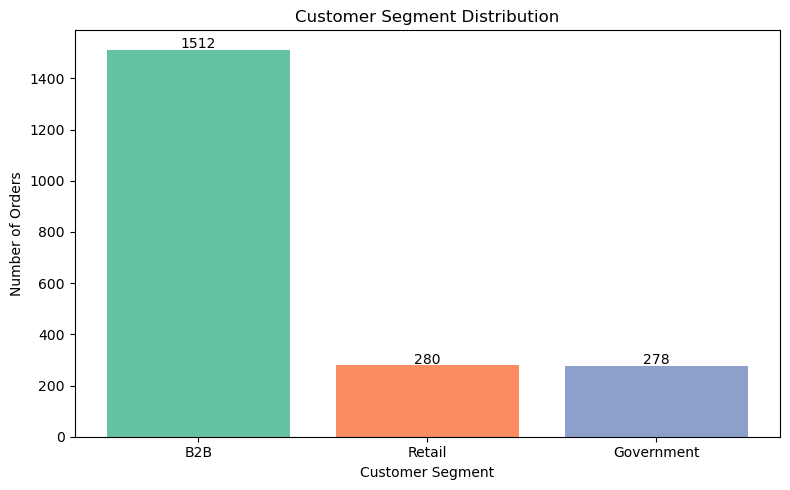

In [32]:
seg = df['Customer_Segment'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
colors = sns.color_palette('Set2', len(seg))
ax.bar(seg.index, seg, color=colors)
ax.set_title('Customer Segment Distribution')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Number of Orders')

for i, v in enumerate(seg):
    ax.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

Tata Steel is primarily a B2B business where most customers are companies not individuals.
Retail and Government are negligible in comparison

#### Which region has the most orders?

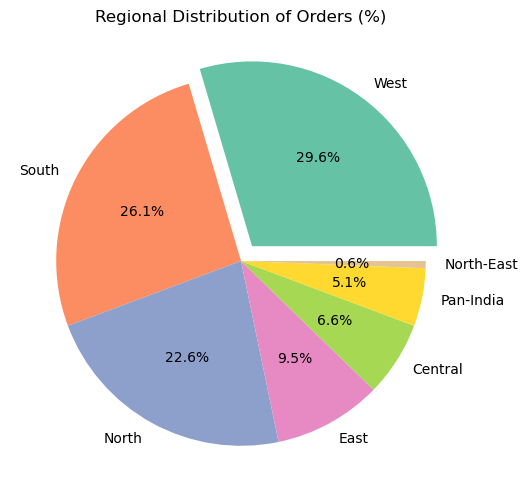

In [35]:
reg_pct = df['Region'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(8,6))
ax.pie(reg_pct,autopct='%1.1f%%',labels=reg_pct.index,explode=[0.1, 0, 0, 0, 0, 0, 0],colors=sns.color_palette('Set2', len(reg_pct)))
ax.set_title('Regional Distribution of Orders (%)')
plt.show()

West dominates with 29.6% of orders, followed by South (26.1%) and North (22.6%).

####  Which grade of steel is most commonly ordered?

In [38]:
df['Grade'].unique()

array(['Fe-550D', 'Fe-500D', 'Fe-600', 'Fe-500-CRS', 'Fe-500-SD',
       'Fe-415', 'Low Carbon', 'Medium Carbon', 'High Carbon', 'EQ-Grade',
       'CHQ-Grade', 'TBW-72A', 'SS-65Mn', 'IS-2062 E250', 'IS-2062 E350',
       'IS-12778', 'IS-12778 E350', 'IS-808', 'EN-8', 'EN-19', 'EN-24',
       'IS-3443', 'UIC-60', 'IS-5986 Fe410', 'IS-1079 D', 'IS-2062 E350B',
       'IS-2062 E450', 'IS-2002 Gr2', 'IS-8500 Fe540B', 'IS-1079 EDD',
       'API-5L X65', 'IS-513 CR1', 'IS-513 CR2', 'IS-513 CR3',
       'IS-513 CR4', 'IS-513 CR5', 'IS-513 D', 'IS-513 EDD',
       'IS-15911 HSLA340', 'IS-277 120GSM', 'IS-277 180GSM',
       'IS-277 275GSM', 'IS-277 350GSM', 'AZ150', 'IF-Grade GI',
       'IS-1239 Medium', 'RAL-5012 Blue', 'RAL-3009 Red',
       'RAL-6005 Green', 'RAL-9002 White', 'Premium PUF',
       'RAL-9003 Signal White', 'MR-T3', 'MR-T4', 'TFS-Grade', 'M4-Grade',
       'M27-Grade', 'IS-1239', 'YST-310', 'EN-10305', 'API-5L X70',
       'CC-Grade', 'BQ-Grade', 'IS-277', 'PPGI', 'SAE-1006

In [39]:
x=df['Grade'].value_counts()
x

Grade
IS-2062 E350      119
Fe-500D           118
IS-2062 E250      118
Fe-550D            79
Fe-415             79
                 ... 
RAL-3009 Red        1
RAL-5012 Blue       1
IS-1239 Medium      1
IF-Grade GI         1
RAL-9002 White      1
Name: count, Length: 68, dtype: int64

Too many unique grades. Grouped rare ones into 'Others':

In [41]:
pd.set_option('display.max_rows', None)
grade_df = df['Grade'].value_counts().reset_index()
grade_df.columns = ['Grade', 'Count']
grade_df

,Grade,Count
0,IS-2062 E350,119
1,Fe-500D,118
2,IS-2062 E250,118
3,Fe-550D,79
4,Fe-415,79
5,IS-12778,78
6,IS-277,77
7,IS-513 CR1,41
8,Low Carbon,40
9,TFS-Grade,40


In [42]:
grade_df[grade_df['Count']>=30].index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41],
      dtype='int64')

In [94]:
grade_counts = df['Grade'].value_counts()
top_grades= grade_counts[grade_counts >= 38].index
df['Grade'] = df['Grade'].apply(
    lambda x: x if x in top_grades else 'Others'
)
df['Grade'].value_counts()

Grade
IS-2062 E350     119
Fe-500D          118
IS-2062 E250     118
Fe-415            79
Fe-550D           79
IS-12778          78
IS-277            77
IS-513 CR1        41
IS-1239           40
Fe-600            40
EN-24             40
EN-19             40
IS-808            40
Low Carbon        40
IS-12778 E350     40
TBW-72A           40
EQ-Grade          40
High Carbon       40
BQ-Grade          40
TFS-Grade         40
MR-T4             39
PPGI              39
API-5L X70        39
EN-10305          39
CC-Grade          39
YST-310           39
M27-Grade         39
M4-Grade          39
IS-3443           39
IS-513 CR4        39
IS-513 CR3        39
IS-513 CR2        39
API-5L X65        39
EN-8              39
SS-65Mn           39
CHQ-Grade         39
Medium Carbon     39
Fe-500-SD         39
Fe-500-CRS        39
SAE-1006          38
MR-T2             38
AZ-150            38
Others            26
Name: count, dtype: int64

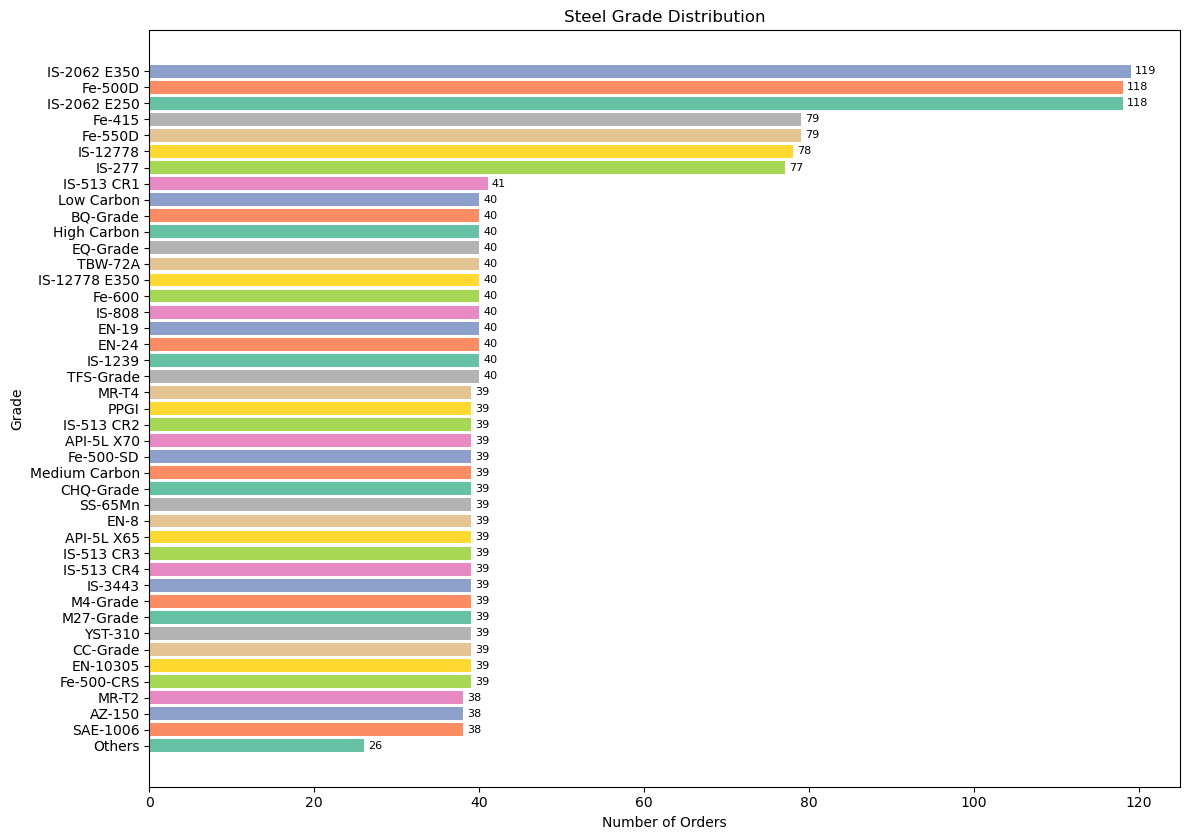

In [140]:
grade = df['Grade'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,8.5))
colors = sns.color_palette('Set2', len(grade))
ax.barh(grade.index, grade, color=colors)
ax.set_title('Steel Grade Distribution')
ax.set_ylabel('Grade')
ax.set_xlabel('Number of Orders')
# plt.xticks(rotation=45, ha='right')

for i, v in enumerate(grade):
    ax.text(v + 0.5,i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

IS-2062 E350 (119) is the most ordered grade followed 
by Fe-500D and IS-2062 E250 (118 each).
Top grades are dominated by structural and TMT bar grades
confirming that construction is the primary application sector.
Others (26 rare grades) grouped together show minimal orders.

#### Which unit of sale is most common?

In [146]:
df['Unit_of_Sale'].value_counts()

Unit_of_Sale
Per Tonne    2031
Per Unit       39
Name: count, dtype: int64

98.1% of all orders are sold Per Tonne, standard for steel industry.
Only 1.9% sold Per Unit.

## Numerical

#### What does the Sales Volume distribution look like? 

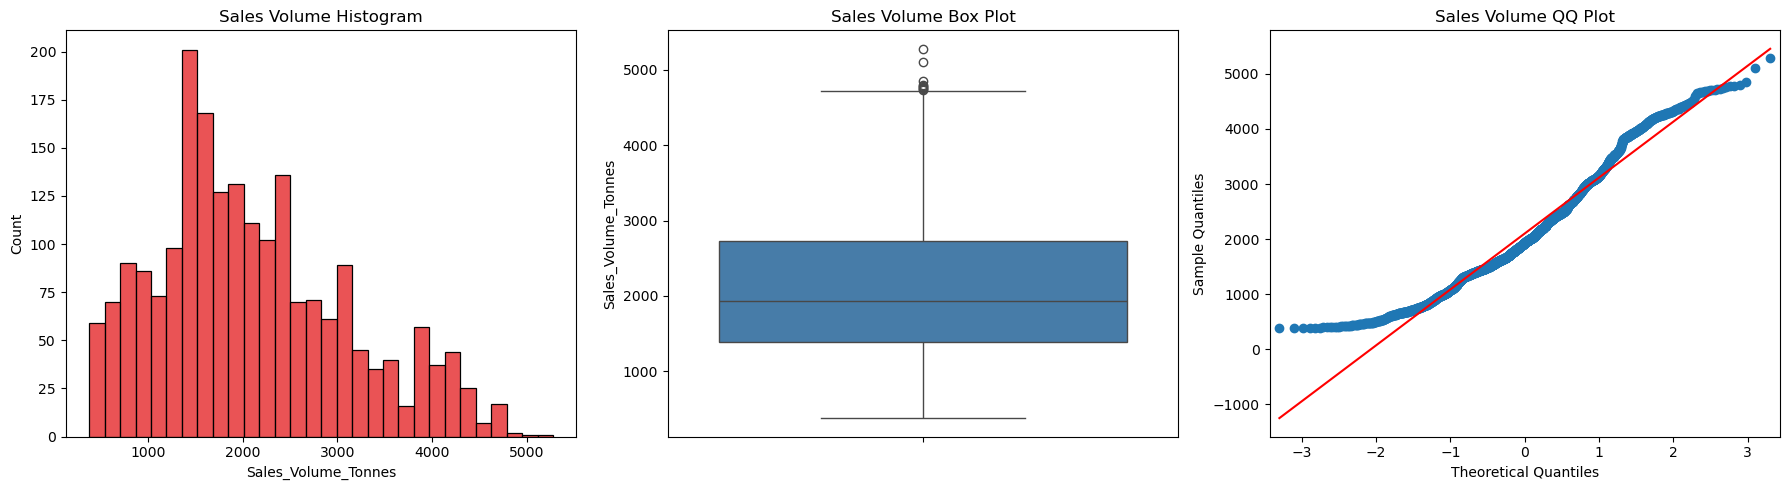

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

palette = sns.color_palette('Set1')

# Histogram
sns.histplot(df['Sales_Volume_Tonnes'], bins=30, 
             ax=axes[0], color=palette[0])
axes[0].set_title('Sales Volume Histogram')

# Box Plot
sns.boxplot(y=df['Sales_Volume_Tonnes'], 
            ax=axes[1], color=palette[1])
axes[1].set_title('Sales Volume Box Plot')

# QQ Plot
from statsmodels.graphics.gofplots import qqplot
qqplot(df['Sales_Volume_Tonnes'], line='s', ax=axes[2])
axes[2].lines[0].set_color(palette[2])
axes[2].set_title('Sales Volume QQ Plot')

plt.tight_layout()
plt.show()

Sales Volume is mildly right skewed with most orders 
between 1000-3000 tonnes. A few outliers exist above 
4500 tonnes.

##### Outlier treatment:

In [169]:
print(df['Sales_Volume_Tonnes'].skew())

0.5815730896174016


In [181]:
Q1 = df['Sales_Volume_Tonnes'].quantile(0.25)
Q3 = df['Sales_Volume_Tonnes'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df['Sales_Volume_Tonnes'] > Q3 + 1.5*IQR) | 
    (df['Sales_Volume_Tonnes'] < Q1 - 1.5*IQR)
]

print(f'Number of outliers: {outliers.shape[0]}')

Number of outliers: 9


Mildly positively skewed (0.58). Only 9 outliers detected 
using IQR method (0.4% of data), likely genuine bulk orders. Apply StandardScaler 
before ML model training.

#### What does the Revenue distribution look like? 

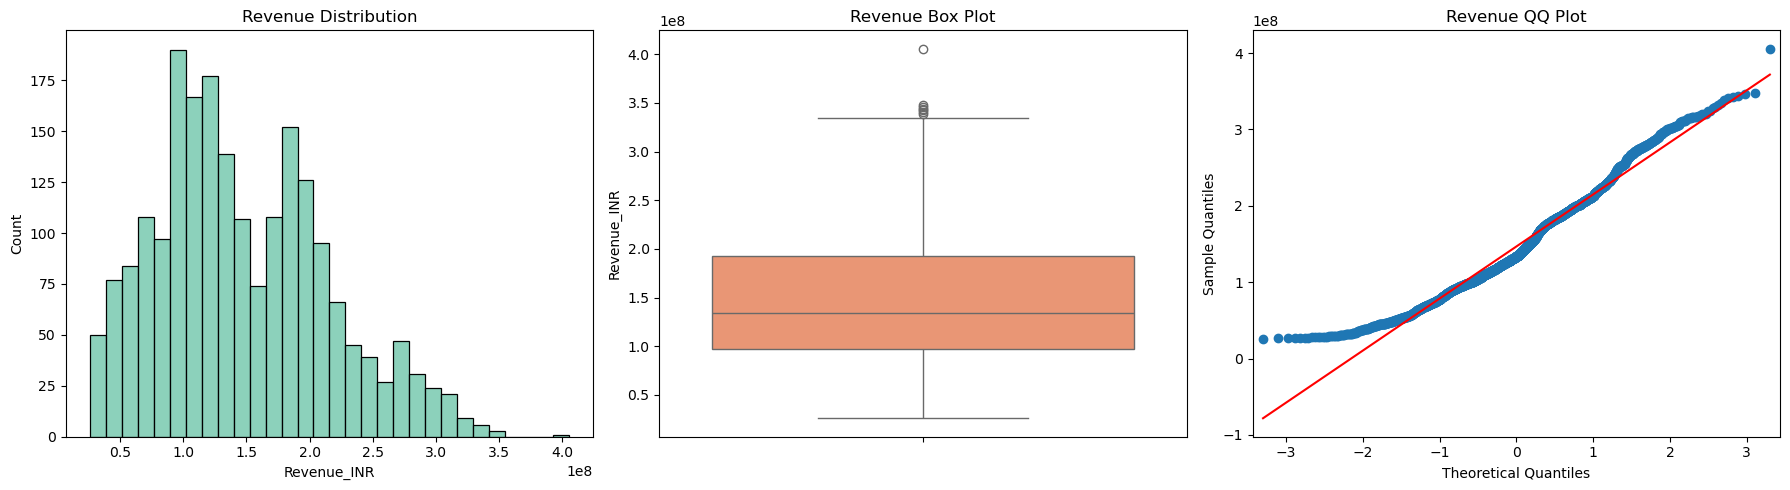

Skewness: 0.5182691165870281
Number of outliers: 7


In [189]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

palette = sns.color_palette('Set2')

# Histogram
sns.histplot(df['Revenue_INR'], bins=30, ax=axes[0], color=palette[0])
axes[0].set_title('Revenue Distribution')

# Box Plot
sns.boxplot(y=df['Revenue_INR'], ax=axes[1], color=palette[1])
axes[1].set_title('Revenue Box Plot')

# QQ Plot
from statsmodels.graphics.gofplots import qqplot
qqplot(df['Revenue_INR'], line='s', ax=axes[2])
axes[2].set_title('Revenue QQ Plot')

plt.tight_layout()
plt.show()

# Skew
print(f'Skewness: {df["Revenue_INR"].skew()}')

# Outliers
Q1 = df['Revenue_INR'].quantile(0.25)
Q3 = df['Revenue_INR'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Revenue_INR'] > Q3 + 1.5*IQR) | (df['Revenue_INR'] < Q1 - 1.5*IQR)]
print(f'Number of outliers: {outliers.shape[0]}')

Skewness and outliers is v low so we leave it as it is.

#### Are Profit Margins consistent or highly variable?

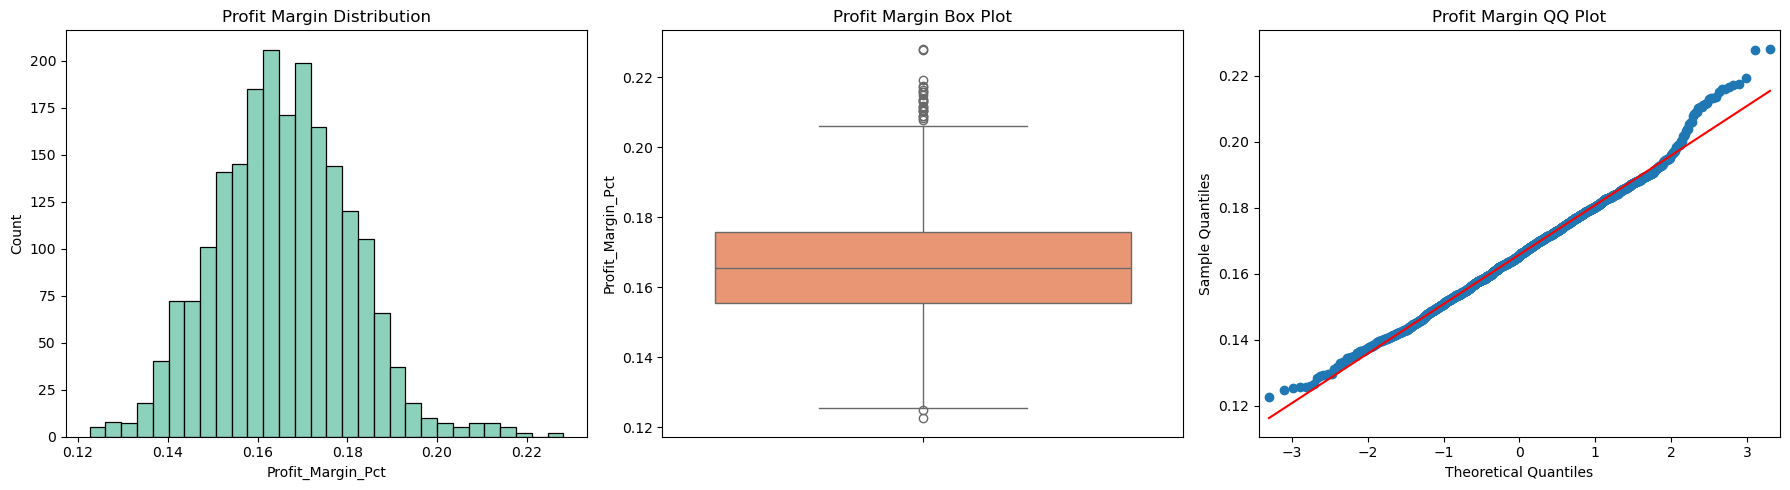

Skewness: 0.237938229393886
Number of outliers: 25


In [193]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

palette = sns.color_palette('Set2')

# Histogram
sns.histplot(df['Profit_Margin_Pct'], bins=30, ax=axes[0], color=palette[0])
axes[0].set_title('Profit Margin Distribution')

# Box Plot
sns.boxplot(y=df['Profit_Margin_Pct'], ax=axes[1], color=palette[1])
axes[1].set_title('Profit Margin Box Plot')

# QQ Plot
from statsmodels.graphics.gofplots import qqplot
qqplot(df['Profit_Margin_Pct'], line='s', ax=axes[2])
axes[2].set_title('Profit Margin QQ Plot')

plt.tight_layout()
plt.show()

# Skew and Outliers
print(f'Skewness: {df["Profit_Margin_Pct"].skew()}')

Q1 = df['Profit_Margin_Pct'].quantile(0.25)
Q3 = df['Profit_Margin_Pct'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Profit_Margin_Pct'] > Q3 + 1.5*IQR) | 
              (df['Profit_Margin_Pct'] < Q1 - 1.5*IQR)]
print(f'Number of outliers: {outliers.shape[0]}')

##### Winsorize:

In [198]:
Q1 = df['Profit_Margin_Pct'].quantile(0.25)
Q3 = df['Profit_Margin_Pct'].quantile(0.75)
IQR = Q3 - Q1

df['Profit_Margin_Pct'] = df['Profit_Margin_Pct'].clip(
    lower=Q1 - 1.5*IQR,
    upper=Q3 + 1.5*IQR
)

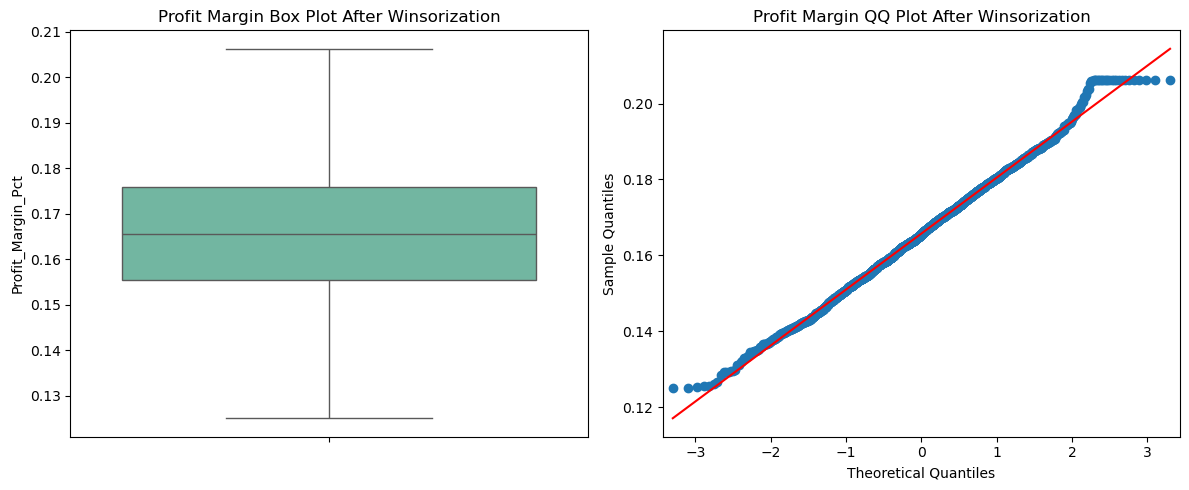

Outliers after winsorization: 0


In [202]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

palette = sns.color_palette('Set2')

sns.boxplot(y=df['Profit_Margin_Pct'], ax=axes[0], color=palette[0])
axes[0].set_title('Profit Margin Box Plot After Winsorization')

qqplot(df['Profit_Margin_Pct'], line='s', ax=axes[1])
axes[1].set_title('Profit Margin QQ Plot After Winsorization')

plt.tight_layout()
plt.show()

# Outliers after
Q1 = df['Profit_Margin_Pct'].quantile(0.25)
Q3 = df['Profit_Margin_Pct'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Profit_Margin_Pct'] > Q3 + 1.5*IQR) | 
              (df['Profit_Margin_Pct'] < Q1 - 1.5*IQR)]
print(f'Outliers after winsorization: {outliers.shape[0]}')

Profit margins are almost normally distributed with a very mild 
positive skew (0.24). 

25 outliers were detected using the IQR method (1.2% of data) — 
these represent unusually high or low profit margin products.

Winsorization was applied to cap these extreme values at the 
IQR boundaries. After treatment, 0 outliers remain.

StandardScaler will be applied before ML model training.

#### Customer Rating, Selling Price per Tonne, Inventory Distribution

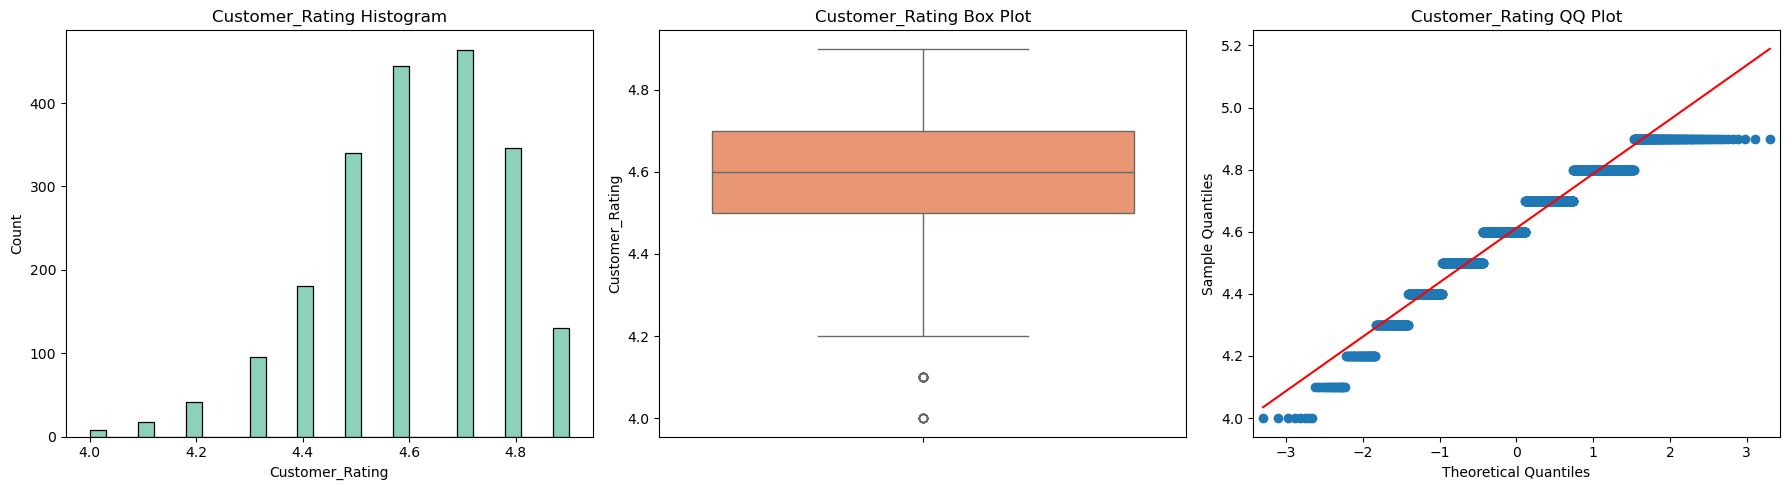

Skew: -0.60
Outliers: 26
---


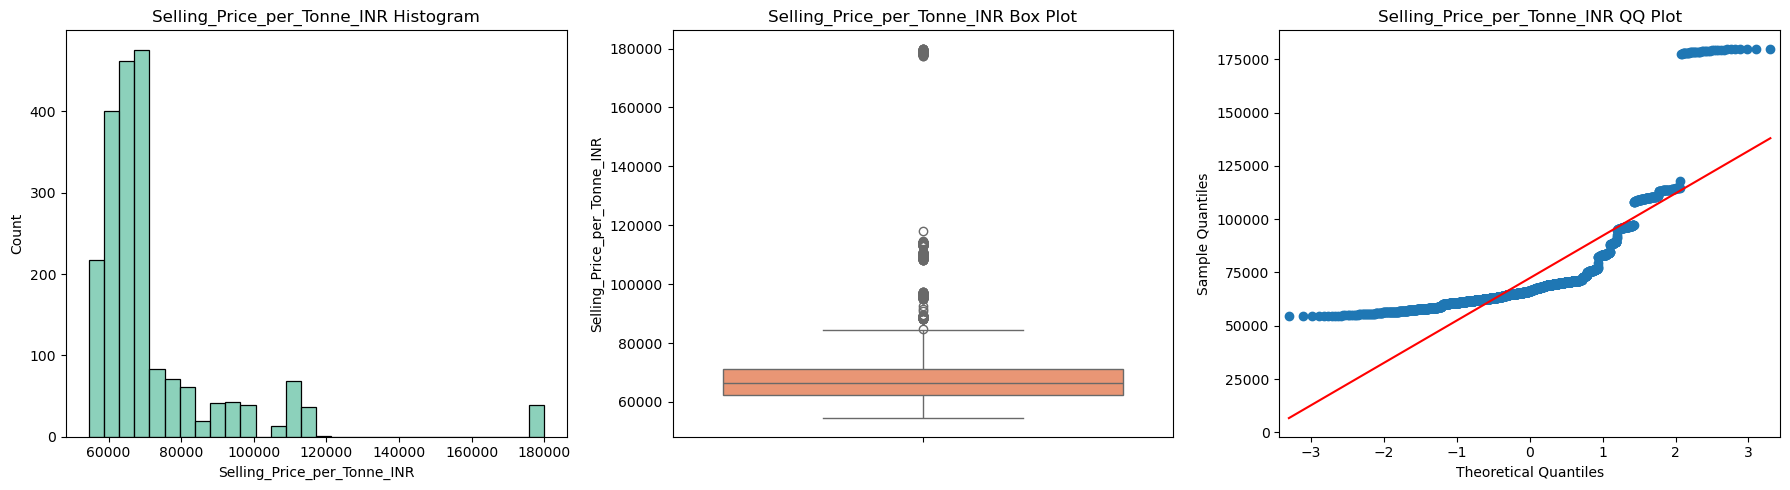

Skew: 3.31
Outliers: 281
---


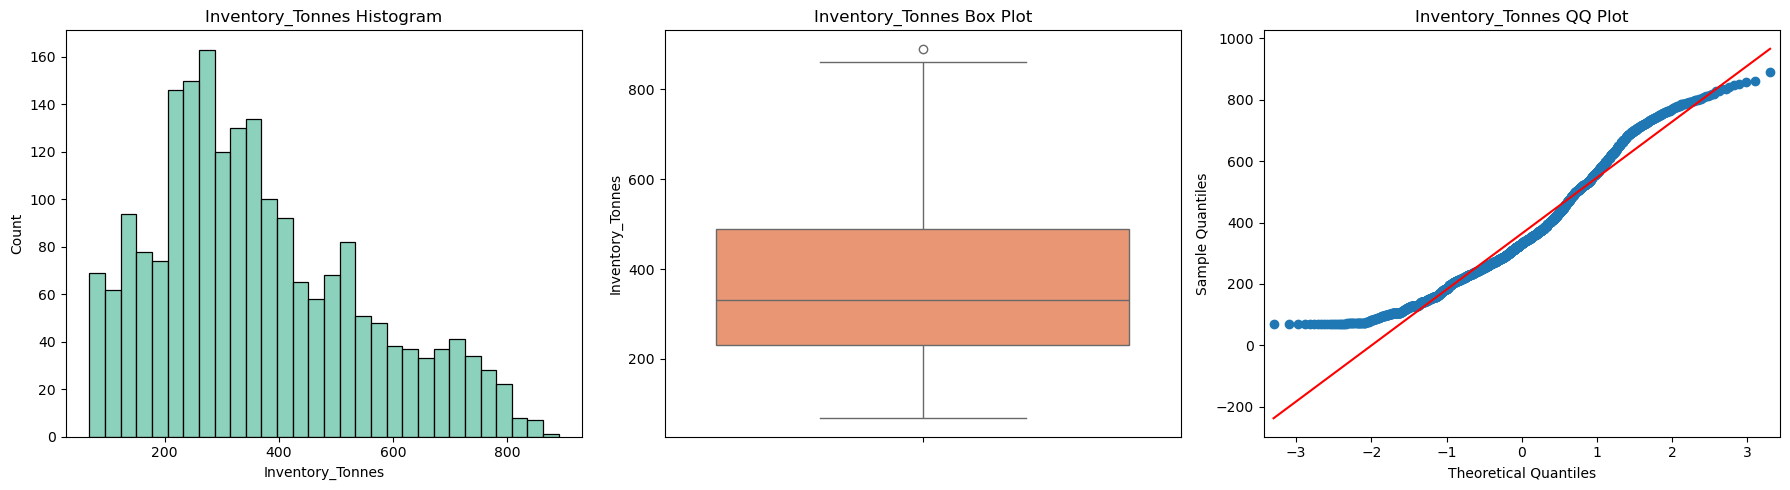

Skew: 0.60
Outliers: 1
---


In [225]:
for col in ['Customer_Rating', 'Selling_Price_per_Tonne_INR', 'Inventory_Tonnes']:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    palette = sns.color_palette('Set2')
    
    sns.histplot(df[col], bins=30, ax=axes[0], color=palette[0])
    axes[0].set_title(f'{col} Histogram')
    
    sns.boxplot(y=df[col], ax=axes[1], color=palette[1])
    axes[1].set_title(f'{col} Box Plot')
    
    qqplot(df[col], line='s', ax=axes[2])
    axes[2].set_title(f'{col} QQ Plot')
    
    plt.tight_layout()
    plt.show()
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] > Q3 + 1.5*IQR) | (df[col] < Q1 - 1.5*IQR)]
    print(f'Skew: {df[col].skew():.2f}')
    print(f'Outliers: {outliers.shape[0]}')
    print('---')

Customer Rating:Slightly left-skewed (most ratings are high, 4.6–4.8). Nearly normal, QQ plot is close to the line.

Selling_Price_per_Tonne_INR: Heavily right-skewed, most prices cluster low (60k–80k) but a long tail of very high prices pulls the mean up. QQ plot curves sharply away from the line.

Inventory_Tonnes:Fairly spread distribution (~100–800 tonnes). QQ plot shows slight deviation at the extremes.

Applying Log Transform to Selling price to reduce skewness:

In [231]:
import numpy as np
from scipy import stats

df['Selling_Price_log'] = np.log1p(df['Selling_Price_per_Tonne_INR'])
print(f"Log skew      : {df['Selling_Price_log'].skew():.2f}")

Log skew      : 2.19


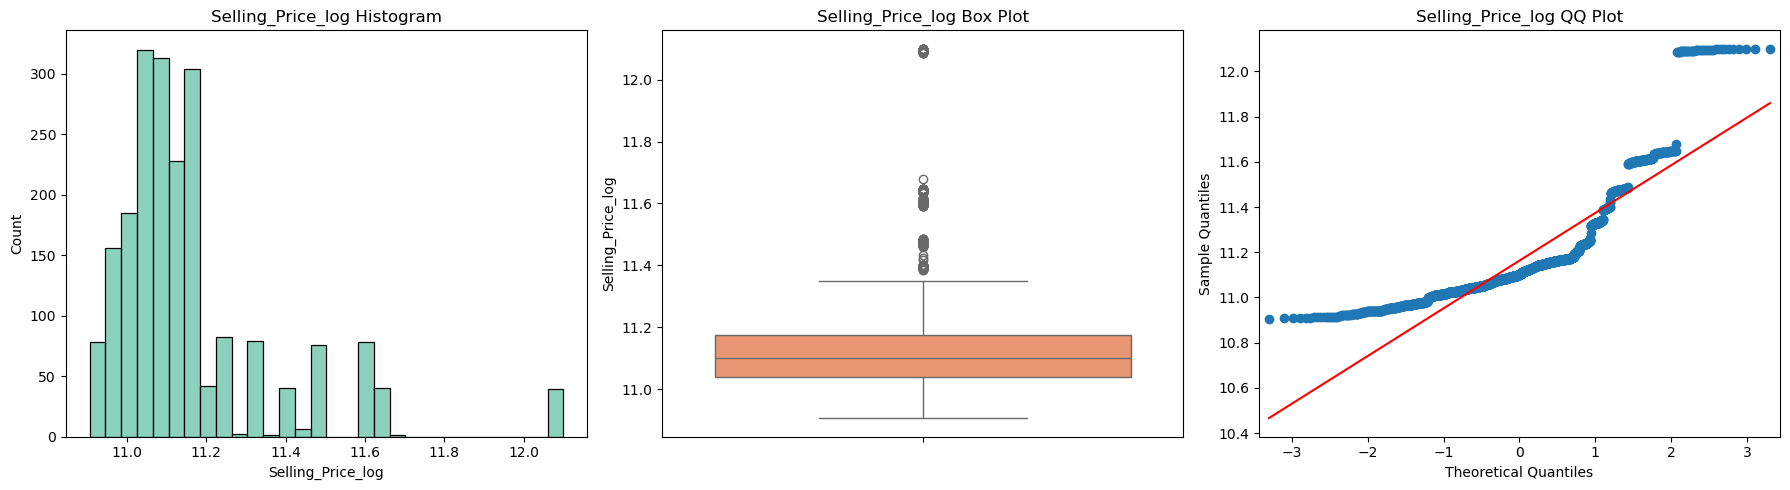

Skew: 2.19
Outliers: 280


In [241]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
palette = sns.color_palette('Set2')

# Bug 1: color=palette should be color=palette[0] for histplot (needs single color)
sns.histplot(df['Selling_Price_log'], bins=30, ax=axes[0], color=palette[0])
axes[0].set_title('Selling_Price_log Histogram')

# Bug 2: same fix for boxplot
sns.boxplot(y=df['Selling_Price_log'], ax=axes[1], color=palette[1])
axes[1].set_title('Selling_Price_log Box Plot')

qqplot(df['Selling_Price_log'], line='s', ax=axes[2])
axes[2].set_title('Selling_Price_log QQ Plot')

plt.tight_layout()
plt.show()

Q1 = df['Selling_Price_log'].quantile(0.25)
Q3 = df['Selling_Price_log'].quantile(0.75)
IQR = Q3 - Q1

# Bug 3: df[col] should be df['Selling_Price_log'] (col variable is from old loop)
outliers = df[(df['Selling_Price_log'] > Q3 + 1.5*IQR) | 
              (df['Selling_Price_log'] < Q1 - 1.5*IQR)]

# Bug 4: nested quotes — use double quotes outside
print(f"Skew: {df['Selling_Price_log'].skew():.2f}")
print(f"Outliers: {outliers.shape[0]}")

In [243]:
from scipy import stats

df['Selling_Price_bc'], _ = stats.boxcox(df['Selling_Price_per_Tonne_INR'])
print(f"Box-Cox skew  : {df['Selling_Price_bc'].skew():.2f}")


Box-Cox skew  : 0.00


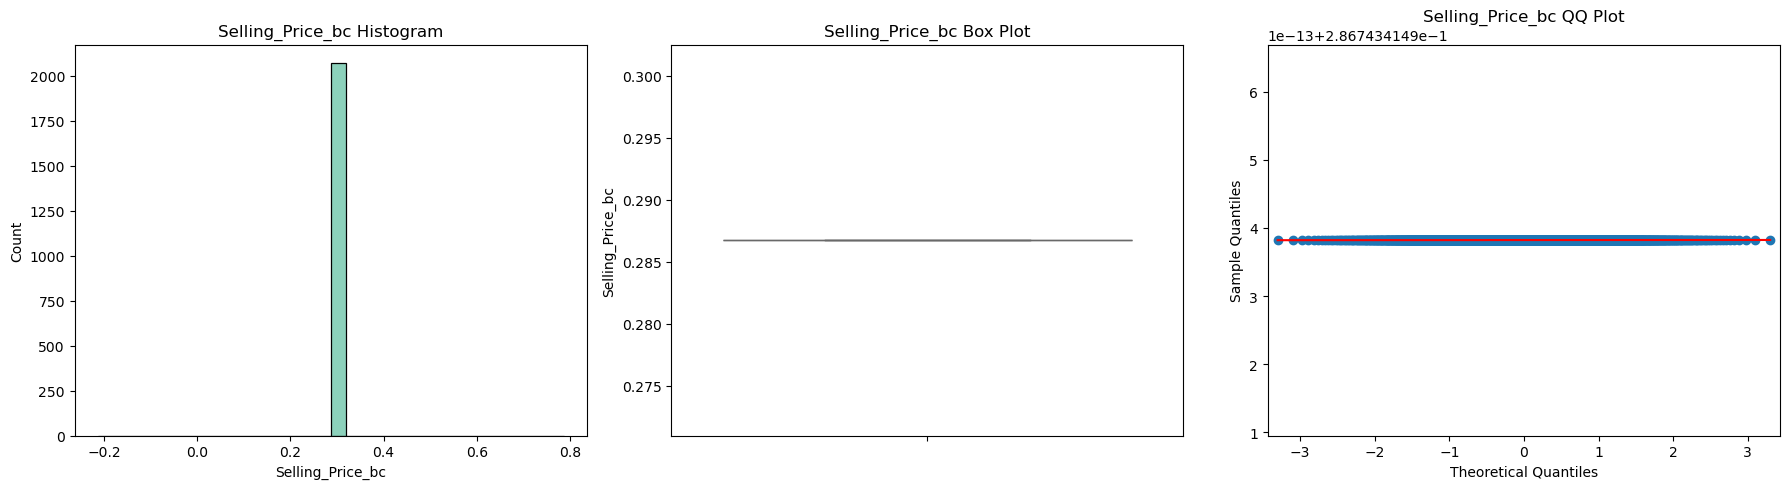

Skew: 0.00
Outliers: 0


In [245]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
palette = sns.color_palette('Set2')

# Bug 1: color=palette should be color=palette[0] for histplot (needs single color)
sns.histplot(df['Selling_Price_bc'], bins=30, ax=axes[0], color=palette[0])
axes[0].set_title('Selling_Price_bc Histogram')

# Bug 2: same fix for boxplot
sns.boxplot(y=df['Selling_Price_bc'], ax=axes[1], color=palette[1])
axes[1].set_title('Selling_Price_bc Box Plot')

qqplot(df['Selling_Price_bc'], line='s', ax=axes[2])
axes[2].set_title('Selling_Price_bc QQ Plot')

plt.tight_layout()
plt.show()

Q1 = df['Selling_Price_bc'].quantile(0.25)
Q3 = df['Selling_Price_bc'].quantile(0.75)
IQR = Q3 - Q1

# Bug 3: df[col] should be df['Selling_Price_log'] (col variable is from old loop)
outliers = df[(df['Selling_Price_bc'] > Q3 + 1.5*IQR) | 
              (df['Selling_Price_bc'] < Q1 - 1.5*IQR)]

# Bug 4: nested quotes — use double quotes outside
print(f"Skew: {df['Selling_Price_bc'].skew():.2f}")
print(f"Outliers: {outliers.shape[0]}")

OverCompressed 

Winsorize and apply log transform:

In [286]:
# Step 1: Cap first
upper = df['Selling_Price_per_Tonne_INR'].quantile(0.86)
lower = df['Selling_Price_per_Tonne_INR'].quantile(0.05)
df['Selling_Price_capped'] = df['Selling_Price_per_Tonne_INR'].clip(lower, upper)

# Step 2: Log transform on capped column
df['Selling_Price_final'] = np.log1p(df['Selling_Price_capped'])

# Step 3: Check
print(f"Skew: {df['Selling_Price_final'].skew():.2f}")

Q1 = df['Selling_Price_final'].quantile(0.25)
Q3 = df['Selling_Price_final'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Selling_Price_final'] > Q3 + 1.5*IQR) | 
              (df['Selling_Price_final'] < Q1 - 1.5*IQR)]
print(f"Outliers: {outliers.shape[0]}")

Skew: 0.57
Outliers: 0


In [288]:
df.shape[1]

26

In [290]:
df.drop(columns=['Selling_Price_log', 'Selling_Price_bc', 'Selling_Price_final'], inplace=True)

In [292]:
df.shape[1]

23

In [294]:
df.columns.tolist()

['Product_ID',
 'Category',
 'Sub_Category',
 'Product_Variant',
 'Grade',
 'Brand',
 'Thickness_mm',
 'Width_mm',
 'Length_m',
 'Weight_per_Unit_kg',
 'Unit_of_Sale',
 'Application_Sector',
 'Customer_Segment',
 'Region',
 'Manufacturing_Plant',
 'Cost_per_Tonne_INR',
 'Selling_Price_per_Tonne_INR',
 'Sales_Volume_Tonnes',
 'Revenue_INR',
 'Profit_Margin_Pct',
 'Inventory_Tonnes',
 'Customer_Rating',
 'Selling_Price_capped']

In [296]:
df.drop(columns=['Selling_Price_capped'],inplace=True)

In [298]:
df.shape[1]

22

We will deal with this later.

# **Bivariate Analysis**

#### Does Sales_Volume_Tonnes decrease as Selling_Price_per_Tonne_INR increases?

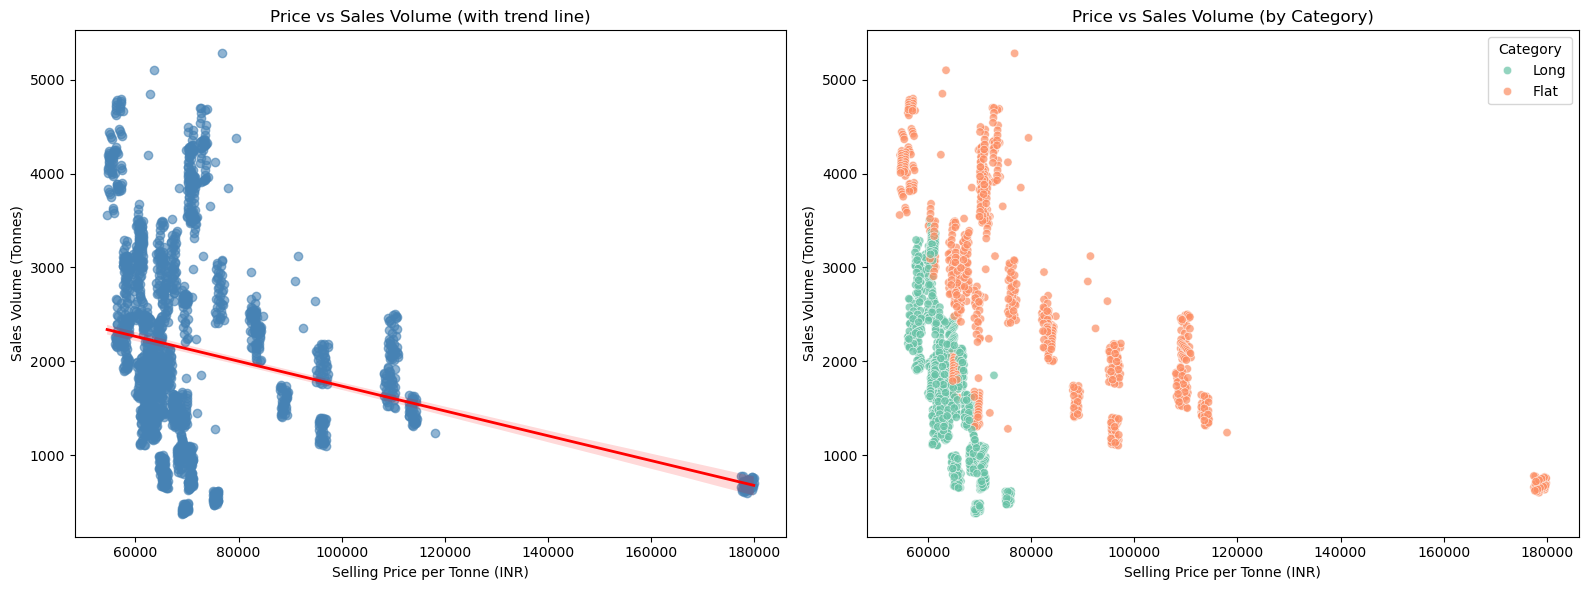

Correlation: -0.2589885142128073
Weak negative relationship


In [322]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    x='Selling_Price_per_Tonne_INR', 
    y='Sales_Volume_Tonnes',
    data=df,
    ax=axes[0],
    scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0].set_title('Price vs Sales Volume (with trend line)')
axes[0].set_xlabel('Selling Price per Tonne (INR)')
axes[0].set_ylabel('Sales Volume (Tonnes)')

sns.scatterplot(
    x='Selling_Price_per_Tonne_INR',
    y='Sales_Volume_Tonnes',
    hue='Category',
    data=df,
    palette='Set2',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Price vs Sales Volume (by Category)')
axes[1].set_xlabel('Selling Price per Tonne (INR)')
axes[1].set_ylabel('Sales Volume (Tonnes)')

plt.tight_layout()
plt.show()
correlation = df['Selling_Price_per_Tonne_INR'].corr(df['Sales_Volume_Tonnes'])
print("Correlation:",correlation)
if correlation < -0.5:
    print("Strong negative relationship")
elif correlation < 0:
    print("Weak negative relationship")
elif correlation > 0.5:
    print("Strong positive relationship")
else:
    print("Weak/no relationship")

The trend line confirms as price increases, volume slightly decreases but it's not a strong effect

Most data is heavily clustered between 55k–80k with volumes of 1000–5000 tonnes.


**Long Products:**

Price barely changes but volume varies a lot.

Sales volume ranges widely from ~500 to 5000 tonnes.

Prices tightly packed between 56k–76k.

**Flat Products:**

Start at 55k and go all the way to 180k (Electrical Steel)

Volume clearly drops as price rises, stronger price-demand effect within Flat

The isolated cluster at 180k has very low volume (700–800 tonnes) could be premium niche products

In [312]:
print(df.groupby('Category')['Selling_Price_per_Tonne_INR'].describe())

high_price = df[df['Selling_Price_per_Tonne_INR'] > 150000]
print("\nProducts with price > 150,000:")
print(high_price[['Category', 'Sub_Category', 'Selling_Price_per_Tonne_INR']].value_counts())

           count          mean           std      min      25%      50%  \
Category                                                                  
Flat       923.0  82397.074756  26097.668676  54500.0  66400.0  71400.0   
Long      1147.0  64235.832607   4386.266573  56100.0  61300.0  63400.0   

              75%       max  
Category                     
Flat      95350.0  179900.0  
Long      67600.0   76100.0  

Products with price > 150,000:
Category  Sub_Category      Selling_Price_per_Tonne_INR
Flat      Electrical Steel  178500.0                       4
                            178200.0                       3
                            177500.0                       2
                            177700.0                       2
                            179800.0                       2
                            179600.0                       2
                            179500.0                       2
                            179300.0                       2
   

This means the Selling Price skew (3.31) was almost entirely driven by Flat, Electrical Steel products. (Premium Product Segment possibly)

#### Which Sub-Category receives the highest and lowest Customer Ratings?

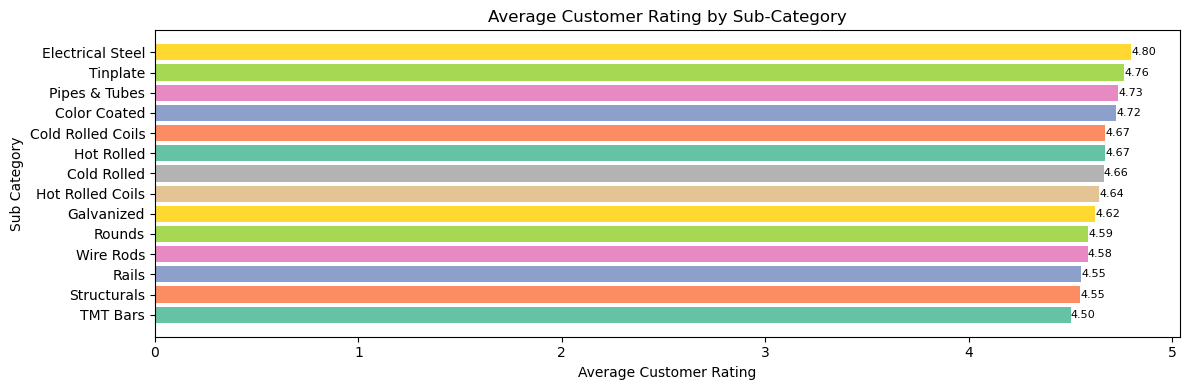

In [361]:
rating_by_sub = df.groupby('Sub_Category')['Customer_Rating'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,4))
colors = sns.color_palette('Set2', len(rating_by_sub))
ax.barh(rating_by_sub.index, rating_by_sub, color=colors)
ax.set_title('Average Customer Rating by Sub-Category')
ax.set_ylabel('Sub Category')
ax.set_xlabel('Average Customer Rating')

for i, v in enumerate(rating_by_sub):
    ax.text(v + 0.001, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

Ratings range only from 4.50 to 4.80 — very narrow band, meaning all sub-categories are rated well overall

Flat products dominate the top (Electrical Steel, Tinplate, Color Coated, Cold Rolled Coils)

Long products cluster at the bottom (TMT Bars, Structurals, Rails, Wire Rods)

#### Does higher Profit_Margin_Pct correlate with higher Customer_Rating? 

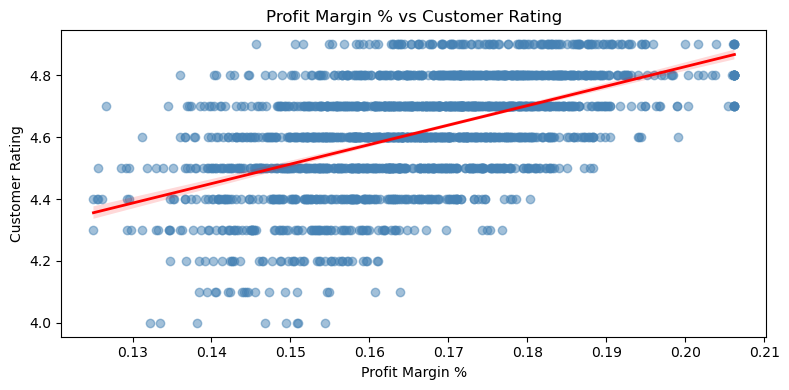

Pearson Correlation: 0.5309
Strong positive, higher margin products are rated better


In [369]:
fig, ax = plt.subplots(figsize=(8,4))

sns.regplot(
    x='Profit_Margin_Pct',
    y='Customer_Rating',
    data=df,
    scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)
ax.set_title('Profit Margin % vs Customer Rating')
ax.set_xlabel('Profit Margin %')
ax.set_ylabel('Customer Rating')

plt.tight_layout()
plt.show()

correlation = df['Profit_Margin_Pct'].corr(df['Customer_Rating'])
print(f"Pearson Correlation: {correlation:.4f}")

if correlation > 0.5:
    print("Strong positive, higher margin products are rated better")
elif correlation > 0:
    print("Weak positive, slight tendency for higher margin = better rating")
elif correlation < -0.5:
    print("Strong negative, higher margin products are rated worse")
else:
    print("Weak/no relationship, margin doesn't drive customer rating")

Most data clusters between margin 0.13–0.17 — that's the typical margin range

High margin products (0.19–0.21) almost exclusively have ratings of 4.8–4.9

Low margin products (0.12–0.13) tend to sit at 4.3–4.4

#### Is Inventory_Tonnes related to Sales_Volume_Tonnes? 

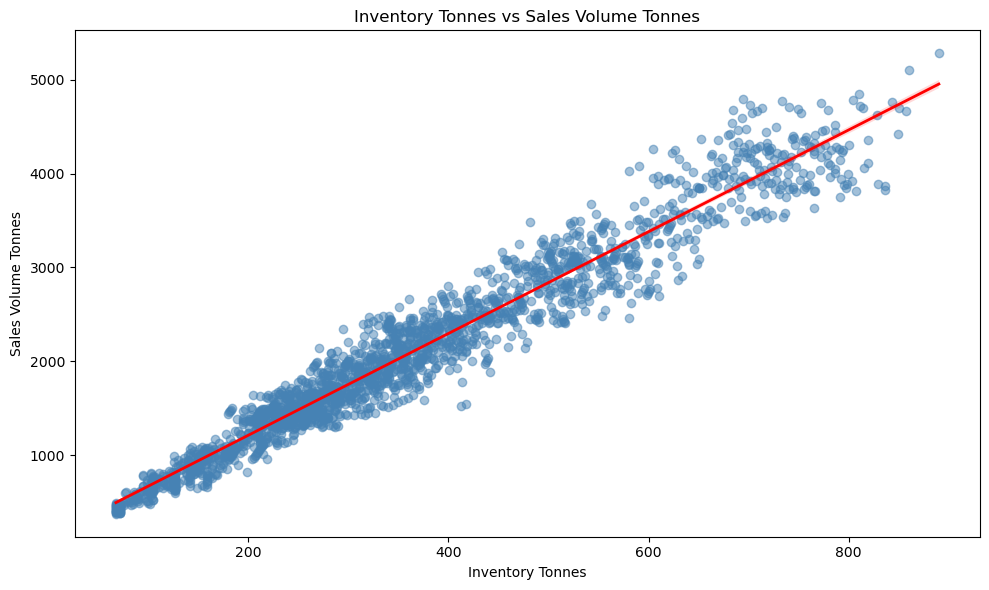

Pearson Correlation: 0.9734
Strong positive, higher inventory products sell more


In [374]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    x='Inventory_Tonnes',
    y='Sales_Volume_Tonnes',
    data=df,
    scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)
ax.set_title('Inventory Tonnes vs Sales Volume Tonnes')
ax.set_xlabel('Inventory Tonnes')
ax.set_ylabel('Sales Volume Tonnes')

plt.tight_layout()
plt.show()

correlation = df['Inventory_Tonnes'].corr(df['Sales_Volume_Tonnes'])
print(f"Pearson Correlation: {correlation:.4f}")

if correlation > 0.5:
    print("Strong positive, higher inventory products sell more")
elif correlation > 0:
    print("Weak positive, slight tendency, more stock = slightly more sales")
elif correlation < -0.5:
    print("Strong negative, overstocking on slow moving products")
else:
    print("Weak/no relationship, inventory levels don't reflect sales")

Dots follow the trend line very tightly.

Relationship is consistent across entire range, from small inventory (100t) to large (900t).

Very few points stray far from the line(predictable pattern).

High demand products are being stocked accordingly.

#### Which Region generates the most Revenue_INR?

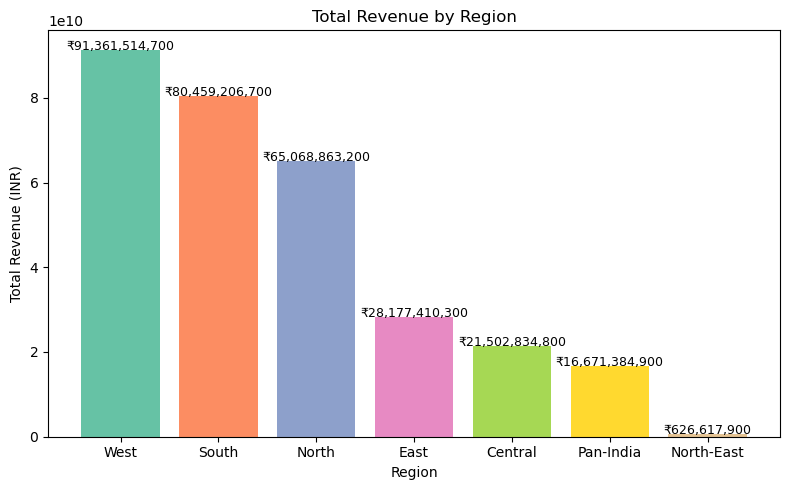

Region
West          9.136151e+10
South         8.045921e+10
North         6.506886e+10
East          2.817741e+10
Central       2.150283e+10
Pan-India     1.667138e+10
North-East    6.266179e+08
Name: Revenue_INR, dtype: float64


In [410]:
region_revenue = df.groupby('Region')['Revenue_INR'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set2', len(region_revenue))
ax.bar(region_revenue.index, region_revenue, color=colors)
ax.set_title('Total Revenue by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Revenue (INR)')

for i, v in enumerate(region_revenue):
    ax.text(i,v + 5,  f'₹{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(df.groupby('Region')['Revenue_INR'].sum().sort_values(ascending=False))

#### Which Customer_Segment (Retail/B2B/Government) has the highest Customer_Rating?

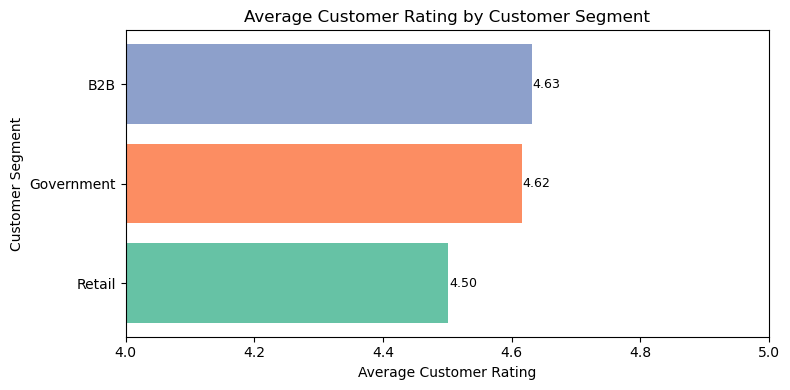

Customer_Segment
B2B           4.63
Government    4.62
Retail        4.50
Name: Customer_Rating, dtype: float64


In [419]:
segment_rating = df.groupby('Customer_Segment')['Customer_Rating'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4
                               ))
colors = sns.color_palette('Set2', len(segment_rating))
ax.barh(segment_rating.index, segment_rating, color=colors)
ax.set_title('Average Customer Rating by Customer Segment')
ax.set_ylabel('Customer Segment')
ax.set_xlabel('Average Customer Rating')
ax.set_xlim(4, 5)  # zoom in since ratings are between 4-5

for i, v in enumerate(segment_rating):
    ax.text(v + 0.001, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(df.groupby('Customer_Segment')['Customer_Rating'].mean().sort_values(ascending=False).round(2))

B2B and Government nearly identical

Retail lowest at 4.50

No segment is genuinely dissatisfied

#### Which Application_Sector has the highest Sales_Volume_Tonnes?

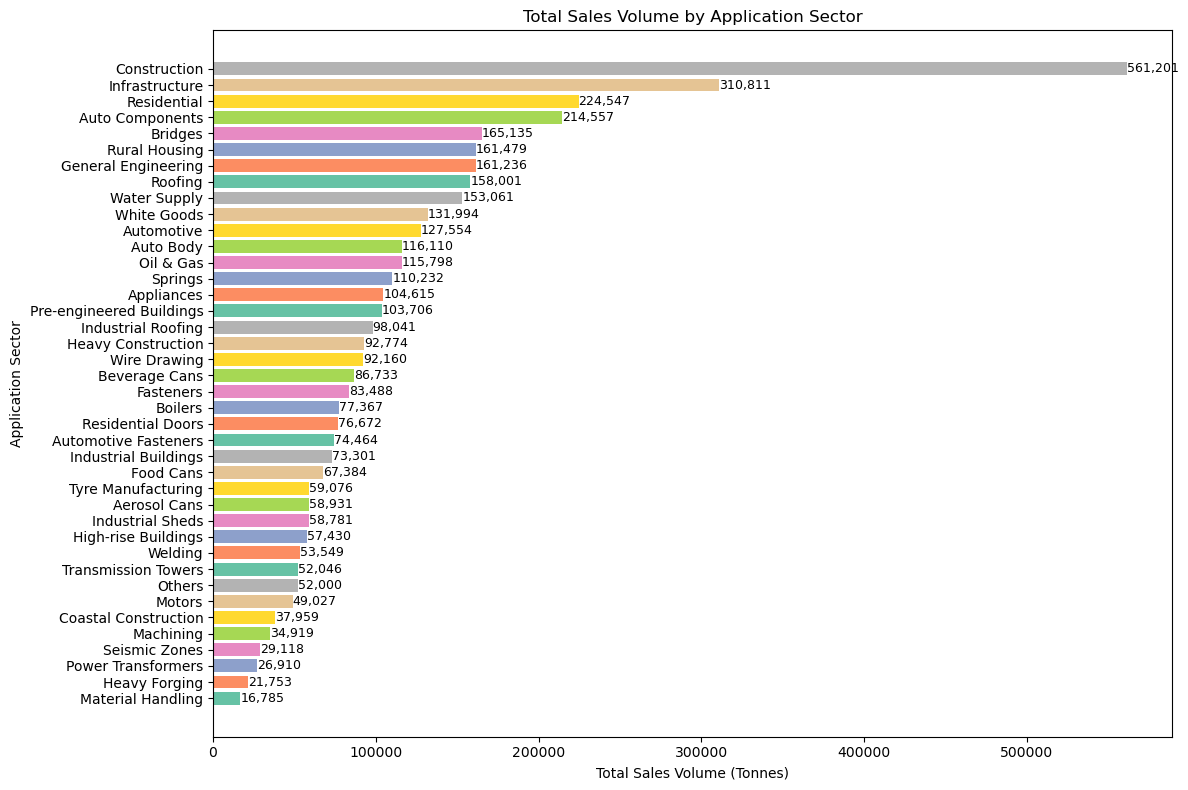

In [425]:
sector_sales = df.groupby('Application_Sector')['Sales_Volume_Tonnes'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('Set2', len(sector_sales))
ax.barh(sector_sales.index, sector_sales, color=colors)
ax.set_title('Total Sales Volume by Application Sector')
ax.set_ylabel('Application Sector')
ax.set_xlabel('Total Sales Volume (Tonnes)')

for i, v in enumerate(sector_sales):
    ax.text(v + 0.5, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# **Multivariate Analysis:**

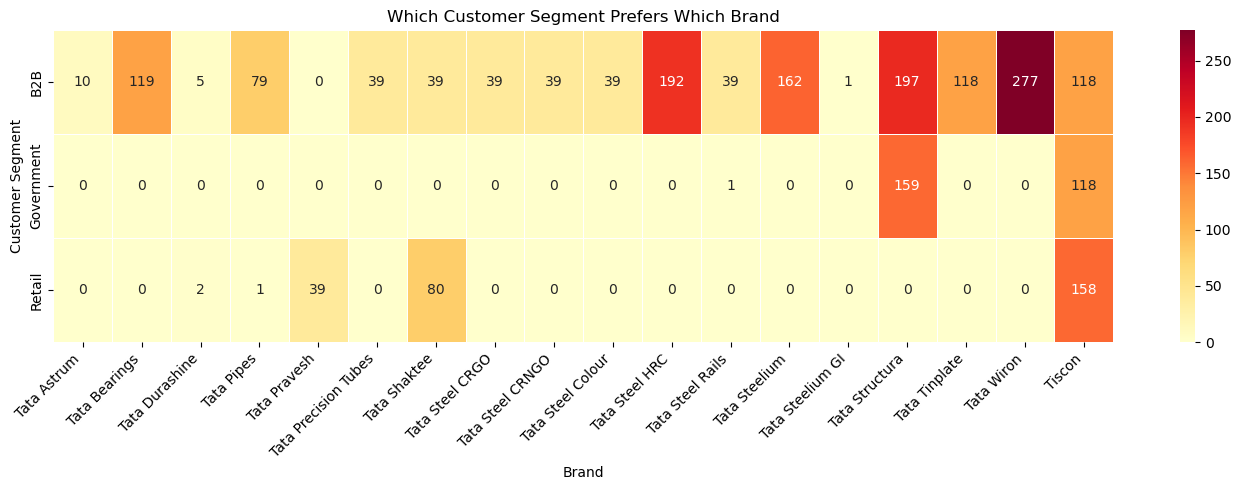

In [434]:
brand_segment = df.groupby(['Customer_Segment', 'Brand']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    brand_segment,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Which Customer Segment Prefers Which Brand')
ax.set_xlabel('Brand')
ax.set_ylabel('Customer Segment')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # fixed

plt.tight_layout()
plt.show()

**B2B**

Most diverse buyer, purchases across nearly all brands

Top brands: Tata Wiron (277), Tata Structura (197), Tata Steel Colour (192)

Driven by industrial and manufacturing requirements across multiple sectors

**Government**

Highly focused, purchases concentrated in just 2 brands

Tata Structura (159) and Tiscon (118) account for almost all government purchases

Reflects infrastructure and civil construction project requirements

**Retail**

Narrowest purchasing pattern of all three segments

Tiscon (158) dominates, followed by Tata Shaktee (80) and Tata Pravesh (39)

Entirely driven by residential construction and home improvement needs

#### Which Sub-Categories are most purchased by each Customer Segment?

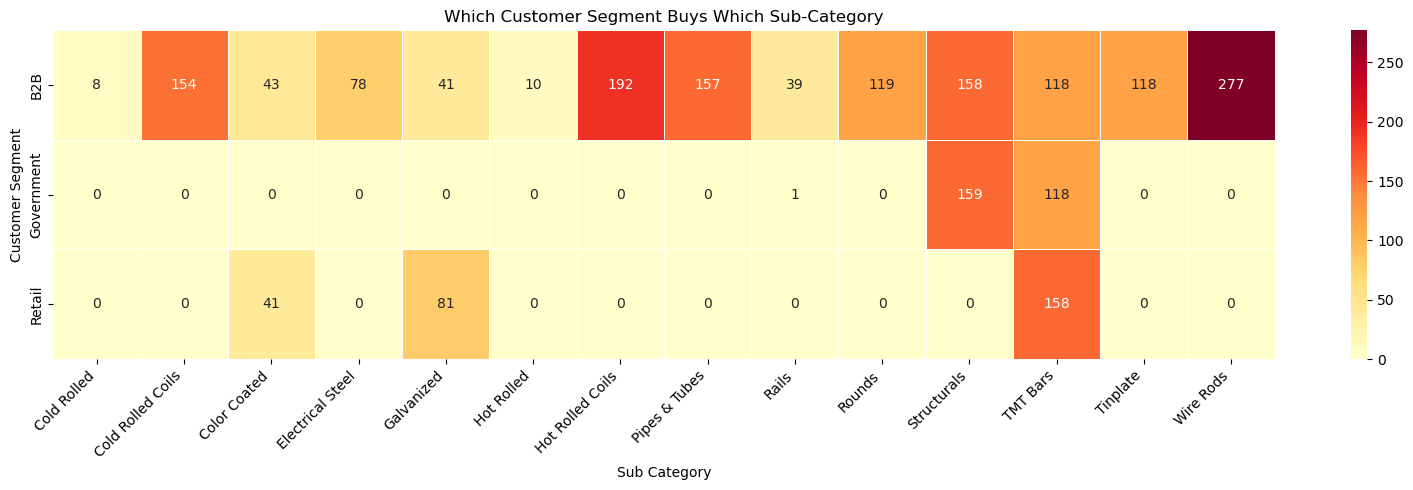

In [439]:
segment_sub = df.groupby(['Customer_Segment', 'Sub_Category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    segment_sub,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Which Customer Segment Buys Which Sub-Category')
ax.set_xlabel('Sub Category')
ax.set_ylabel('Customer Segment')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

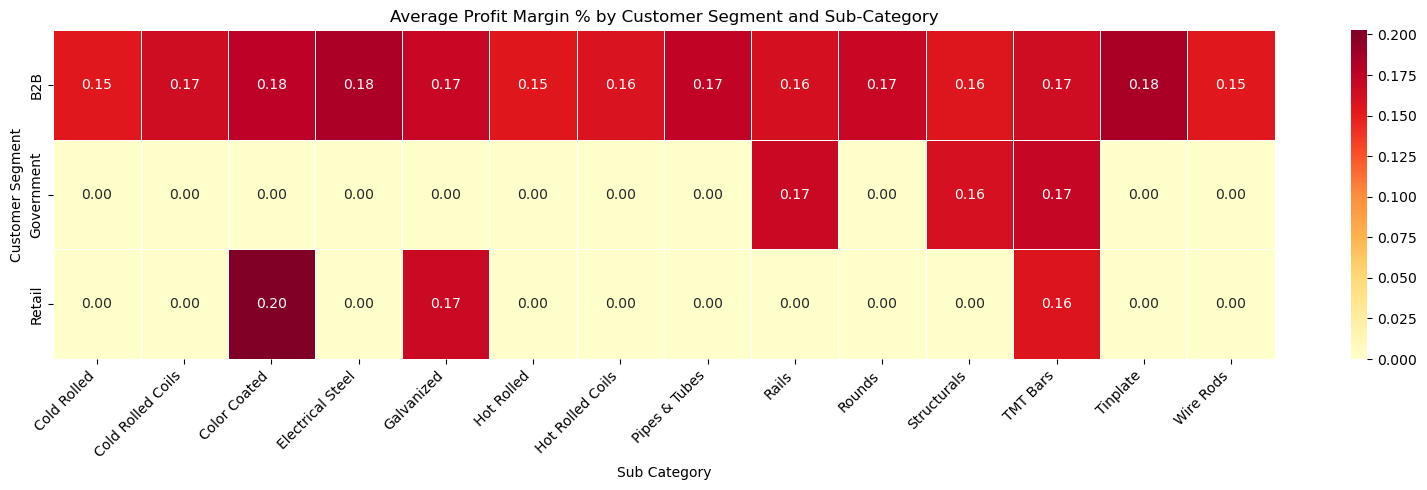

Customer_Segment  Sub_Category    
Retail            Color Coated        0.2025
B2B               Tinplate            0.1848
                  Electrical Steel    0.1837
                  Color Coated        0.1763
                  Pipes & Tubes       0.1742
Government        TMT Bars            0.1717
B2B               Rounds              0.1703
                  Galvanized          0.1702
Government        Rails               0.1690
Retail            Galvanized          0.1681
Name: Profit_Margin_Pct, dtype: float64


In [441]:
segment_margin = df.groupby(['Customer_Segment', 'Sub_Category'])['Profit_Margin_Pct'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    segment_margin,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Average Profit Margin % by Customer Segment and Sub-Category')
ax.set_xlabel('Sub Category')
ax.set_ylabel('Customer Segment')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Top 5 most profitable combinations
print(df.groupby(['Customer_Segment', 'Sub_Category'])['Profit_Margin_Pct']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .round(4))

**B2B**

Top performing combinations are Tinplate (0.18), Electrical Steel (0.18) and Color Coated (0.18). This makes B2B the most reliable and diversified segment from a profitability standpoint.

**Govt**

Government purchasing is highly concentrated — only Rails (0.17), Structurals (0.16) and TMT Bars (0.17).

**Retail**

Despite being the lowest rated customer segment, it contains the single highest profit margin in the entire dataset, Color Coated at 0.20. Galvanized (0.17) and TMT Bars (0.16).

#### Which category sells best in which region?

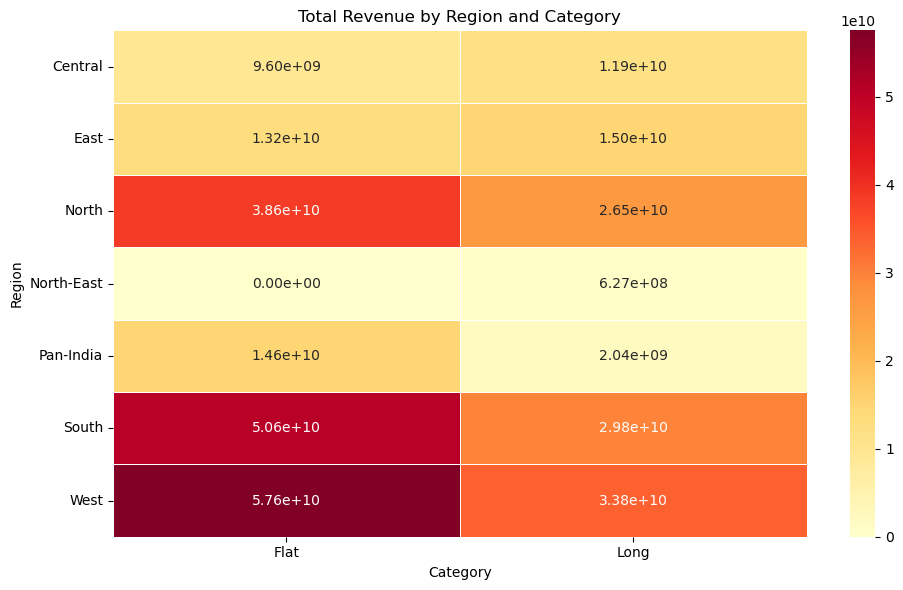

In [451]:
region_category = df.groupby(['Region', 'Category'])['Revenue_INR'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    region_category,
    annot=True,
    fmt='.2e',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Total Revenue by Region and Category')
ax.set_xlabel('Category')
ax.set_ylabel('Region')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.show()

### CORRELATION MATRIX

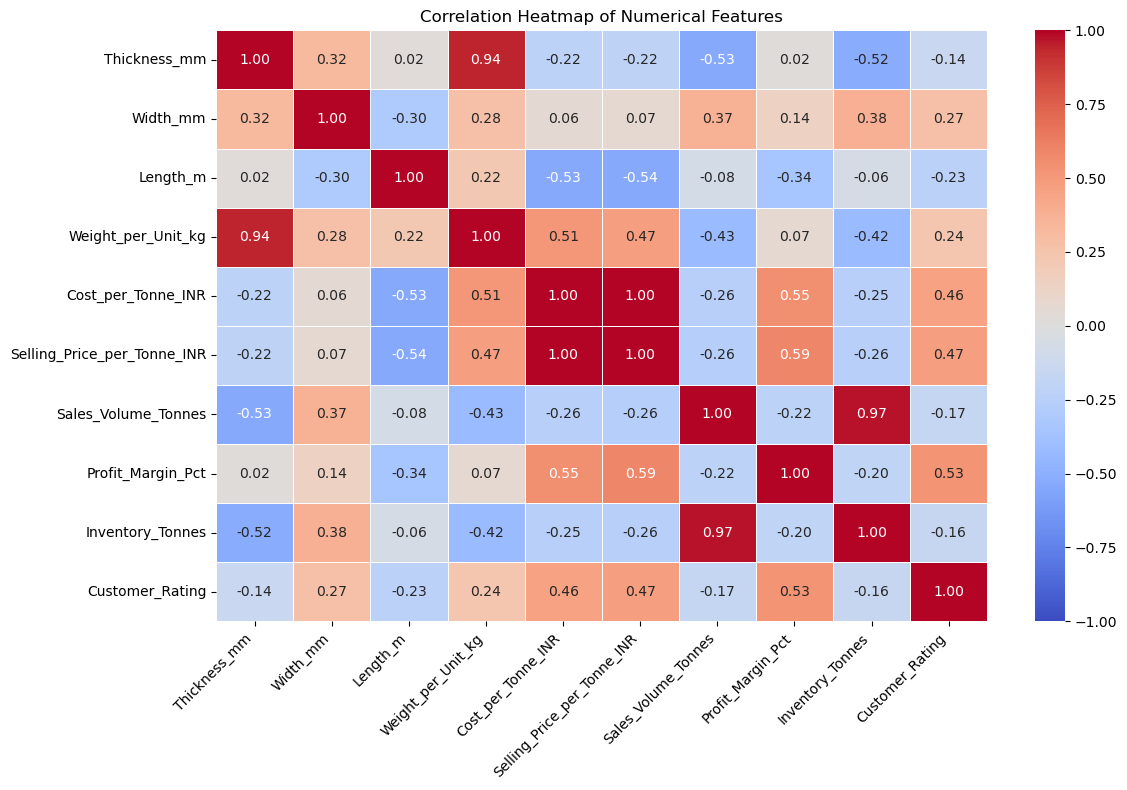

In [456]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include='number').drop(columns=['Revenue_INR'])

corr_matrix = numerical_cols.corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)
ax.set_title('Correlation Heatmap of Numerical Features')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Positive Correlations**

Cost per Tonne vs Selling Price per Tonne (1.00)
Perfect correlation, selling price is directly derived from cost.

Inventory Tonnes vs Sales Volume Tonnes (0.97)
Confirmed from bivariate analysis, inventory is almost perfectly demand driven.

Thickness mm vs Weight per Unit kg (0.94)
Physically expected, thicker steel products are naturally heavier. 

**Negative Correlation**

Thickness mm vs Sales Volume (-0.53)
Thicker products sell in lower volumes 

Length m vs Cost per Tonne (-0.53)
Longer products tend to be cheaper per tonne

Thickness mm vs Inventory (-0.52)
Heavy thick products are stocked in smaller quantities
